# Phase 3: Synset Enrichment and Hierarchy-Based Semantic Similarity

This notebook enriches the semantic layer by using the existing Concept -> Synset mapping to add WordNet-based hierarchy information (hypernym_of, hyponym_of) and semantic similarity. 

This improves game generation 

## 1. Imports and Graph Loading

In [ ]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import wordnet as wn
from tqdm import tqdm
import os
import itertools

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

# Set paths
ARTIFACTS_DIR = 'artifacts'
INPUT_GRAPH = os.path.join(ARTIFACTS_DIR, 'graph_phase2_scriptweights.graphml')
OUT_HIERARCHY_CSV = os.path.join(ARTIFACTS_DIR, 'synset_hierarchy_edges.csv')
OUT_SIMILARITY_CSV = os.path.join(ARTIFACTS_DIR, 'concept_similarity_edges.csv')
OUTPUT_GRAPH = os.path.join(ARTIFACTS_DIR, 'graph_phase3_semantics.graphml')

# Load graph
print(f"Loading graph from {INPUT_GRAPH}...")
G = nx.read_graphml(INPUT_GRAPH)
print(f"Loaded {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/sushantpokharel/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Loading graph from artifacts/graph_phase2_scriptweights.graphml...
Loaded 290518 nodes and 307828 edges.


## 1.5 Build Semantic Indexes
This step correctly indexes the semantic layer from the exported Phase 1 / Phase 2 graph.
It uses relation aliases to ensure compatibility.

Also, instead of repeatedly traversing the full graph every time it needs a concept’s English word, target language word, synset, or domain, it builds compact indexes once and reuses them later.



In [2]:
from collections import defaultdict
import re

def norm_value(x):
    if x is None:
        return ""
    return str(x).strip()

def norm_type(x):
    return norm_value(x).lower()

def norm_relation(x):
    return norm_value(x).lower()

def tokenize_text(text):
    text = norm_value(text).lower()
    return [t for t in re.findall(r"[\w']+", text) if t]

REL_ALIASES = {
    "mapped_to_synset": {"mapped_to_synset", "mappedtosynset"},
    "belongs_to_domain": {"belongs_to_domain", "belongstodomain"},
    "english_label_for": {"english_label_for", "englishlabelfor"},
    "target_label_for": {"target_label_for", "targetlabelfor"},
    "romanised_as": {"romanised_as", "romanisedas"},
}

def rel_is(edge_data, canonical_name):
    r = norm_relation(edge_data.get("relation"))
    return r in REL_ALIASES[canonical_name]

def build_semantic_indexes(G):
    idx = {
        "concepts": set(),
        "concept_to_domains": defaultdict(set),
        "concept_to_synsets": defaultdict(set),
        "concept_to_eng_lemmas": defaultdict(set),
        "concept_to_lang_lemmas": defaultdict(lambda: defaultdict(set)),
        "concept_to_roman_lemmas": defaultdict(lambda: defaultdict(set)),
        "domain_to_concepts": defaultdict(set),
        "synset_to_concepts": defaultdict(set),
        "eng_token_to_concepts": defaultdict(set),
    }

    for n, data in G.nodes(data=True):
        if norm_type(data.get("type")) == "concept":
            idx["concepts"].add(n)

    for c in idx["concepts"]:
        for _, v, d in G.out_edges(c, data=True):
            if rel_is(d, "belongs_to_domain"):
                idx["concept_to_domains"][c].add(v)
                idx["domain_to_concepts"][v].add(c)
            elif rel_is(d, "mapped_to_synset"):
                idx["concept_to_synsets"][c].add(v)
                idx["synset_to_concepts"][v].add(c)

    for nodeid, data in G.nodes(data=True):
        t = norm_type(data.get("type"))
        lang = norm_value(data.get("language")).lower()
        text = norm_value(data.get("text")).lower()

        if t == "lemma-eng":
            for _, c, d in G.out_edges(nodeid, data=True):
                if rel_is(d, "english_label_for"):
                    idx["concept_to_eng_lemmas"][c].add(text)
                    for tok in tokenize_text(text):
                        idx["eng_token_to_concepts"][tok].add(c)

        elif t == "lemma-lang":
            concept_targets = []
            roman_targets = []

            for _, v, d in G.out_edges(nodeid, data=True):
                if rel_is(d, "target_label_for"):
                    concept_targets.append(v)
                    idx["concept_to_lang_lemmas"][v][lang].add(text)
                elif rel_is(d, "romanised_as"):
                    roman_targets.append(v)

            roman_texts = []
            for rnode in roman_targets:
                rdata = G.nodes[rnode]
                rtext = norm_value(rdata.get("text")).lower()
                if rtext:
                    roman_texts.append(rtext)

            for c in concept_targets:
                for rtext in roman_texts:
                    idx["concept_to_roman_lemmas"][c][lang].add(rtext)

    return idx

def summarize_semantic_indexes(idx):
    summary = {
        "concepts_total": len(idx["concepts"]),
        "concepts_with_domains": sum(1 for c in idx["concepts"] if idx["concept_to_domains"].get(c)),
        "concepts_with_synsets": sum(1 for c in idx["concepts"] if idx["concept_to_synsets"].get(c)),
        "concepts_with_english": sum(1 for c in idx["concepts"] if idx["concept_to_eng_lemmas"].get(c)),
        "concepts_with_target_lemmas": sum(1 for c in idx["concepts"] if idx["concept_to_lang_lemmas"].get(c)),
        "concepts_with_roman_lemmas": sum(1 for c in idx["concepts"] if idx["concept_to_roman_lemmas"].get(c)),
        "domain_nodes_indexed": len(idx["domain_to_concepts"]),
        "synset_nodes_indexed": len(idx["synset_to_concepts"]),
        "english_tokens_indexed": len(idx["eng_token_to_concepts"]),
    }
    return summary

def sample_nodes_by_type(G, ntype, k=5):
    out = []
    target = ntype.lower()
    for n, d in G.nodes(data=True):
        if norm_type(d.get("type")) == target:
            out.append((n, dict(d)))
            if len(out) >= k:
                break
    return out

def sample_concept_record(G, idx, concept_id=None):
    if concept_id is None:
        for c in idx["concepts"]:
            if idx["concept_to_eng_lemmas"].get(c):
                concept_id = c
                break

    if concept_id is None:
        return None

    record = {
        "concept_id": concept_id,
        "domains": sorted(idx["concept_to_domains"].get(concept_id, [])),
        "synsets": sorted(idx["concept_to_synsets"].get(concept_id, [])),
        "english_lemmas": sorted(idx["concept_to_eng_lemmas"].get(concept_id, [])),
        "target_lemmas": {
            lang: sorted(vals)
            for lang, vals in idx["concept_to_lang_lemmas"].get(concept_id, {}).items()
        },
        "roman_lemmas": {
            lang: sorted(vals)
            for lang, vals in idx["concept_to_roman_lemmas"].get(concept_id, {}).items()
        },
    }
    return record


### 1.5.1 Validate Semantic Indexes

Here it proves the semantic layer was read correctly from the exported graph in previous phases/passes. 
The sample record also shows the structure clearly. 

one concept can have English labels, multiple target-language labels, domain links, synset links, and romanized forms.

In [3]:
idx = build_semantic_indexes(G)
summary = summarize_semantic_indexes(idx)

print("Semantic index summary")
for k, v in summary.items():
    print(f"- {k}: {v}")

print("\nSample Concept nodes")
for item in sample_nodes_by_type(G, "Concept", 3):
    print(item)

print("\nSample Lemma-eng nodes")
for item in sample_nodes_by_type(G, "Lemma-eng", 3):
    print(item)

print("\nSample Domain nodes")
for item in sample_nodes_by_type(G, "Domain", 3):
    print(item)

print("\nSample Synset nodes")
for item in sample_nodes_by_type(G, "Synset", 3):
    print(item)

print("\nSample concept record")
print(sample_concept_record(G, idx))


Semantic index summary
- concepts_total: 108719
- concepts_with_domains: 108569
- concepts_with_synsets: 108569
- concepts_with_english: 12741
- concepts_with_target_lemmas: 12742
- concepts_with_roman_lemmas: 5950
- domain_nodes_indexed: 45
- synset_nodes_indexed: 108569
- english_tokens_indexed: 18422

Sample Concept nodes
('concept:10', {'type': 'Concept', 'concept_id': '10'})
('concept:100', {'type': 'Concept', 'concept_id': '100'})
('concept:1000', {'type': 'Concept', 'concept_id': '1000'})

Sample Lemma-eng nodes
('lemma:eng:entity', {'type': 'Lemma-eng', 'language': 'eng', 'text': 'entity'})
('lemma:eng:name', {'type': 'Lemma-eng', 'language': 'eng', 'text': 'name'})
('lemma:eng:component', {'type': 'Lemma-eng', 'language': 'eng', 'text': 'component'})

Sample Domain nodes
('domain:adj.all', {'type': 'Domain', 'domain': 'adj.all'})
('domain:noun.act', {'type': 'Domain', 'domain': 'noun.act'})
('domain:noun.animal', {'type': 'Domain', 'domain': 'noun.animal'})

Sample Synset node

## 2. Inspect Semantic Layer

### Identify all **Synset** and **Concept** nodes. Extract their **wn30_id** to map them to NLTK WordNet synsets.

In [4]:
# Extract Synset and Concept nodes
synset_nodes = {n: d for n, d in G.nodes(data=True) if d.get('type') == 'Synset'}
concept_nodes = {n: d for n, d in G.nodes(data=True) if d.get('type') == 'Concept'}

print(f"Found {len(synset_nodes)} Synset nodes and {len(concept_nodes)} Concept nodes.")

def wn30_id_to_synset(wn30_id):
    """Converts a WordNet 3.0 ID (e.g., '00699207-a') to an NLTK Synset."""
    try:
        offset_str, pos = wn30_id.split('-')
        offset = int(offset_str)
        if pos == 's': pos = wn.ADJ_SAT
        return wn.synset_from_pos_and_offset(pos, offset)
    except Exception as e:
        return None

# Build mappings
synset_to_wn = {}
wn_to_synset = {}
for node_id, data in synset_nodes.items():
    if 'wn30_id' in data:
        nltk_synset = wn30_id_to_synset(data['wn30_id'])
        if nltk_synset:
            synset_to_wn[node_id] = nltk_synset
            wn_to_synset[nltk_synset] = node_id

print(f"Successfully mapped {len(synset_to_wn)} synsets to NLTK WordNet.")


Found 108569 Synset nodes and 108719 Concept nodes.
Successfully mapped 108569 synsets to NLTK WordNet.


## 3. Build Synset Hierarchy Edge Table
We'll extract **hypernym_of** and **hyponym_of** relations for our mapped synsets. We only add edges if both synsets exist in our graph.

In [5]:
hierarchy_edges = []

for node_id, synset in tqdm(synset_to_wn.items(), desc="Extracting Hierarchy Edges"):
    # Hypernyms
    for hypernym in synset.hypernyms():
        if hypernym in wn_to_synset:
            target_node = wn_to_synset[hypernym]
            # node_id is hyponym_of target_node
            hierarchy_edges.append({
                'source': node_id,
                'target': target_node,
                'relation': 'hyponym_of',
                'weight': 1.0
            })
            # target_node is hypernym_of node_id
            hierarchy_edges.append({
                'source': target_node,
                'target': node_id,
                'relation': 'hypernym_of',
                'weight': 1.0
            })

hierarchy_df = pd.DataFrame(hierarchy_edges).drop_duplicates()
print(f"Generated {len(hierarchy_df)} hierarchy edges.")

# Save to CSV
hierarchy_df.to_csv(OUT_HIERARCHY_CSV, index=False)
print(f"Saved hierarchy edges to {OUT_HIERARCHY_CSV}")


Extracting Hierarchy Edges: 100%|██████████| 108569/108569 [00:00<00:00, 729228.95it/s]


Generated 174104 hierarchy edges.
Saved hierarchy edges to artifacts/synset_hierarchy_edges.csv


### 3.1 Validate + Visualize Hierarchy

Hierarchy Relations Counts:
relation
hyponym_of     87052
hypernym_of    87052
Name: count, dtype: int64


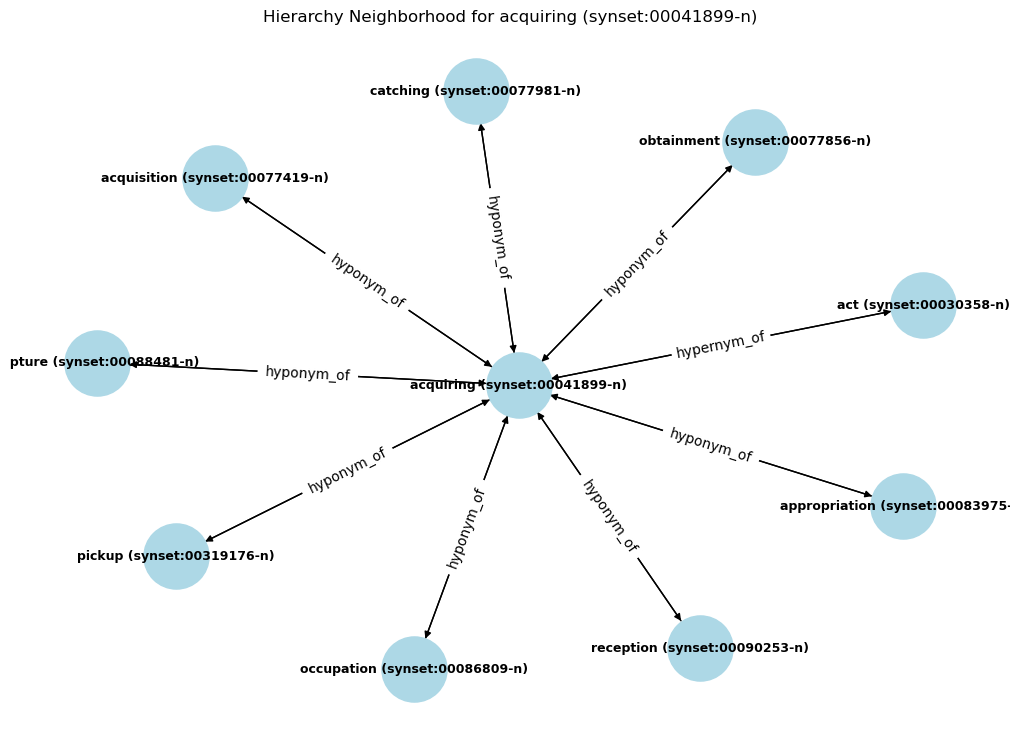

In [11]:
# Validation
print("Hierarchy Relations Counts:")
print(hierarchy_df['relation'].value_counts())

# Visualization
sample_node = hierarchy_df['source'].iloc[0]
sample_edges = hierarchy_df[
    (hierarchy_df['source'] == sample_node) |
    (hierarchy_df['target'] == sample_node)
]

H = nx.DiGraph()
for _, row in sample_edges.iterrows():
    H.add_edge(row['source'], row['target'], label=row['relation'])

labels = {}
for node in H.nodes():
    if node in synset_to_wn:
        try:
            word = synset_to_wn[node].lemmas()[0].name().replace('_', ' ')
            labels[node] = f"{word} ({node})"
        except:
            labels[node] = node
    else:
        labels[node] = node

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(H, seed=42)

nx.draw(
    H, pos,
    labels=labels,
    with_labels=True,
    node_color='lightblue',
    node_size=2200,
    font_size=9,
    font_weight='bold'
)
nx.draw_networkx_edge_labels(
    H, pos,
    edge_labels=nx.get_edge_attributes(H, 'label')
)
plt.title(f"Hierarchy Neighborhood for {labels.get(sample_node, sample_node)}")
plt.axis('off')
plt.show()

## 4. Build Concept Similarity Edge Table
We use the Wu-Palmer (wup_similarity) metric. To avoid complexity, we only compute similarity for: 
 ### concepts whose synsets are related via shared hypernyms (co-hyponyms) or direct parent/child relationships.

In [ ]:
# First,  Map Concept to Synset
concept_to_synset = {}
synset_to_concepts = {}

for u, v, data in G.edges(data=True):
    if data.get('relation') == 'mapped_to_synset':
        if u.startswith('concept:') and v.startswith('synset:'):
            concept_to_synset[u] = v
            if v not in synset_to_concepts:
                synset_to_concepts[v] = []
            synset_to_concepts[v].append(u)

print(f"Mapped {len(concept_to_synset)} concepts to synsets.")

# Second,  Find related synset pairs (e.g. sharing a hypernym or direct path)
candidate_synset_pairs = set()

# Direct hypernym/hyponym pairs
for _, row in hierarchy_df.iterrows():
    s, t = row['source'], row['target']
    candidate_synset_pairs.add((min(s, t), max(s, t)))

# sharing the same hypernym --> co-hyponyms

hypernyms = hierarchy_df[hierarchy_df['relation'] == 'hypernym_of']
hypernym_groups = hypernyms.groupby('source')['target'].apply(list).to_dict()

for hypernym, hyponyms in hypernym_groups.items():
    if len(hyponyms) > 1:
        
        # All pairs of hyponyms sharing this hypernym are candidates
        for s, t in itertools.combinations(hyponyms, 2):
            candidate_synset_pairs.add((min(s, t), max(s, t)))

print(f"Found {len(candidate_synset_pairs)} candidate related synset pairs.")


Mapped 108569 concepts to synsets.
Found 1542793 candidate related synset pairs.


In [ ]:
# 3. Calculate wup_similarity (Wu-Palmer ) for these pairs
similarity_edges = []
THRESHOLD = 0.7

for s1, s2 in tqdm(candidate_synset_pairs, desc="Computing Similarity"):
    wn1 = synset_to_wn.get(s1)
    wn2 = synset_to_wn.get(s2)
    if wn1 and wn2:
        sim = wn1.wup_similarity(wn2)
        if sim and sim >= THRESHOLD:
            # Map back to concepts
            c1_list = synset_to_concepts.get(s1, [])
            c2_list = synset_to_concepts.get(s2, [])
            
            for c1 in c1_list:
                for c2 in c2_list:
                    similarity_edges.append({
                        'source': c1,
                        'target': c2,
                        'relation': 'concept_similarity',
                        'weight': round(sim, 4)
                    })
                    similarity_edges.append({
                        'source': c2,
                        'target': c1,
                        'relation': 'concept_similarity',
                        'weight': round(sim, 4)
                    })

sim_df = pd.DataFrame(similarity_edges).drop_duplicates()
print(f"Generated {len(sim_df)} concept similarity edges with similarity >= {THRESHOLD}.")

# Save to CSV
sim_df.to_csv(OUT_SIMILARITY_CSV, index=False)
print(f"Saved concept similarity edges to {OUT_SIMILARITY_CSV}")


Computing Similarity: 100%|██████████| 1542793/1542793 [02:51<00:00, 8996.28it/s]


Generated 2694420 concept similarity edges with similarity >= 0.7.
Saved concept similarity edges to artifacts/concept_similarity_edges.csv


### 4.1 Validate + Visualize Concept Similarity

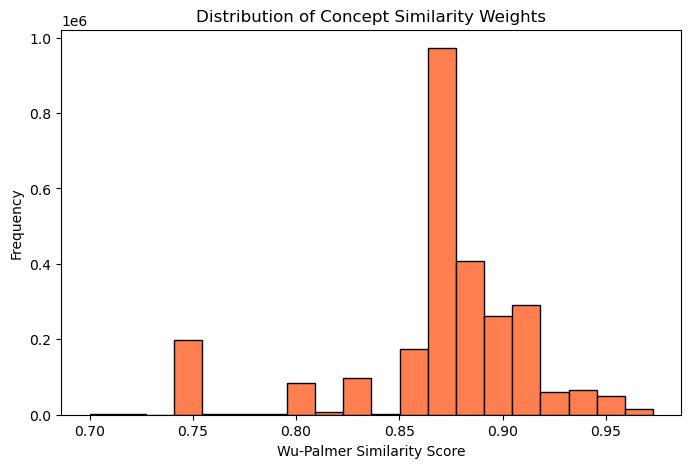

Top 5 similarity pairs:
                source         target            relation  weight
1715916  concept:13675  concept:13678  concept_similarity   0.973
490987   concept:12439  concept:12414  concept_similarity   0.973
1805420  concept:13675  concept:13679  concept_similarity   0.973
2043063  concept:12438  concept:12414  concept_similarity   0.973
1284614  concept:12414  concept:12423  concept_similarity   0.973


In [14]:
# Distribution of similarity weights
plt.figure(figsize=(8, 5))
plt.hist(sim_df['weight'], bins=20, color='coral', edgecolor='black')
plt.title("Distribution of Concept Similarity Weights")
plt.xlabel("Wu-Palmer Similarity Score")
plt.ylabel("Frequency")
plt.show()

# Sample of highest similarities
print("Top 5 similarity pairs:")
print(sim_df.sort_values(by='weight', ascending=False).head(5))


## 5. Attach Edges into Graph
We now inject these two CSVs into our main graph `G`.

In [15]:
print(f"Graph nodes before injection: {G.number_of_nodes()}")
print(f"Graph edges before injection: {G.number_of_edges()}")

# Inject Hierarchy
for _, row in hierarchy_df.iterrows():
    if G.has_node(row['source']) and G.has_node(row['target']):
        G.add_edge(row['source'], row['target'], relation=row['relation'], weight=row['weight'])

# Inject Similarity
for _, row in sim_df.iterrows():
    if G.has_node(row['source']) and G.has_node(row['target']):
        G.add_edge(row['source'], row['target'], relation=row['relation'], weight=row['weight'])

print(f"Graph nodes after injection: {G.number_of_nodes()}")
print(f"Graph edges after injection: {G.number_of_edges()}")


Graph nodes before injection: 290518
Graph edges before injection: 307828
Graph nodes after injection: 290518
Graph edges after injection: 3176352


### 5.1 Multi-Hop Traversal Demo
Let's trace: Concept -> Synset -> Hypernym -> Concept

In [16]:
# Find a concept that has a synset with a hypernym
start_concept = None
for u, v, d in G.edges(data=True):
    if d.get('relation') == 'hyponym_of':
        # u is synset, v is hypernym synset
        hyponym_concepts = synset_to_concepts.get(u, [])
        hypernym_concepts = synset_to_concepts.get(v, [])
        if hyponym_concepts and hypernym_concepts:
            start_concept = hyponym_concepts[0]
            hyper_concept = hypernym_concepts[0]
            print(f"Multi-hop Path:")
            print(f"1. Start Concept: {start_concept}")
            print(f"2. Mapped Synset: {u}")
            print(f"3. Hypernym Synset: {v}")
            print(f"4. Hypernym Concept: {hyper_concept}")
            break


Multi-hop Path:
1. Start Concept: concept:100
2. Mapped Synset: synset:00041899-n
3. Hypernym Synset: synset:00030358-n
4. Hypernym Concept: concept:58


## 6. DEMO based on these edges
Using the graph and the semantic indexes to find semantic distractors for a Matching Game.

In [63]:
def find_demo_concept_for_language(lang_code, G, idx, difficulty='hard', min_distractors=1):
    candidates = []

    for c in idx['concepts']:
        eng_lemmas = list(idx['concept_to_eng_lemmas'].get(c, []))
        target_lemmas = list(idx['concept_to_lang_lemmas'].get(c, {}).get(lang_code, []))
        if not eng_lemmas or not target_lemmas:
            continue

        distractors = get_semantic_distractors(c, lang_code, G, idx, difficulty=difficulty, max_distractors=10)
        if len(distractors) >= min_distractors:
            candidates.append((c, eng_lemmas[0], target_lemmas[0], len(distractors)))

    if not candidates:
        return None, None, None

    candidates = sorted(candidates, key=lambda x: x[3], reverse=True)
    return candidates[0][:3]

In [64]:
def get_semantic_distractors(concept_id, target_language_code, G, idx, difficulty='medium', max_distractors=3):
    similar_concepts = []

    for neighbor in G.successors(concept_id):
        edge_data = G.get_edge_data(concept_id, neighbor)
        edge_items = edge_data.items() if isinstance(edge_data, dict) and 'relation' not in edge_data else {0: edge_data}.items()

        for _, attrs in edge_items:
            if attrs.get('relation') != 'concept_similarity':
                continue

            w = float(attrs.get('weight', 0.0))
            lang_lemmas = list(idx['concept_to_lang_lemmas'].get(neighbor, {}).get(target_language_code, []))
            if not lang_lemmas:
                continue

            if difficulty == 'hard' and w >= 0.85:
                similar_concepts.append((neighbor, w, lang_lemmas[0]))
            elif difficulty == 'medium' and 0.75 <= w < 0.85:
                similar_concepts.append((neighbor, w, lang_lemmas[0]))
            elif difficulty == 'easy' and 0.70 <= w < 0.75:
                similar_concepts.append((neighbor, w, lang_lemmas[0]))
            break

    seen = set()
    distractors = []
    for c, w, lemma in sorted(similar_concepts, key=lambda x: x[1], reverse=True):
        if lemma not in seen:
            distractors.append({'lemma': lemma, 'concept': c, 'similarity': w})
            seen.add(lemma)
        if len(distractors) == max_distractors:
            break

    return distractors

In [71]:
concept_id = 'concept:102'
lang_code = 'np'

correct_answers = list(idx['concept_to_lang_lemmas'].get(concept_id, {}).get(lang_code, []))
correct_answer = correct_answers[0] if correct_answers else "N/A"

distractors = get_semantic_distractors(concept_id, lang_code, G, idx, difficulty='medium')

print(f"Correct answer: {correct_answer}")
print("Distractors:")
for i, d in enumerate(distractors, 1):
    print(f"{i}. {d['lemma']}")

Correct answer: प्रसूति
Distractors:
1. कार्यकलाप
2. आर्जन
3. बँडाइ


## 7. Export Final GraphML
Save the graph with all new phase 3 nodes/edges into `artifacts/`.

In [39]:
print(f"Saving final Phase 3 GraphML to {OUTPUT_GRAPH}...")
nx.write_graphml(G, OUTPUT_GRAPH)
print("Save complete.")


Saving final Phase 3 GraphML to artifacts/graph_phase3_semantics.graphml...
Save complete.
